In [31]:
import pandas as pd
from matplotlib import pyplot as plt
df = pd.read_csv('Airlinesatisfaction.csv')
plt.style.use("fivethirtyeight")

Data Quality

In [32]:
df.isnull().sum()

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [33]:
df.duplicated().sum()

np.int64(0)

Data Structure and Types


In [34]:
df.shape

(25976, 25)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

Customer Satisfaction


In [36]:
satisfaction_counts = df['satisfaction'].value_counts()
print(satisfaction_counts)

satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64


Text(0, 0.5, 'count')

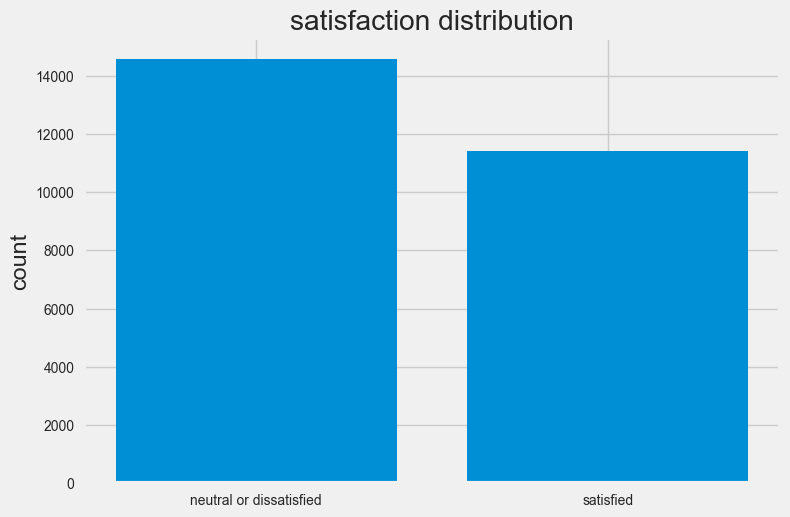

In [37]:
plt.bar(satisfaction_counts.index, satisfaction_counts.values)

plt.title('satisfaction distribution')
plt.ylabel('count')

Age Distribution


Text(0, 0.5, 'Freq')

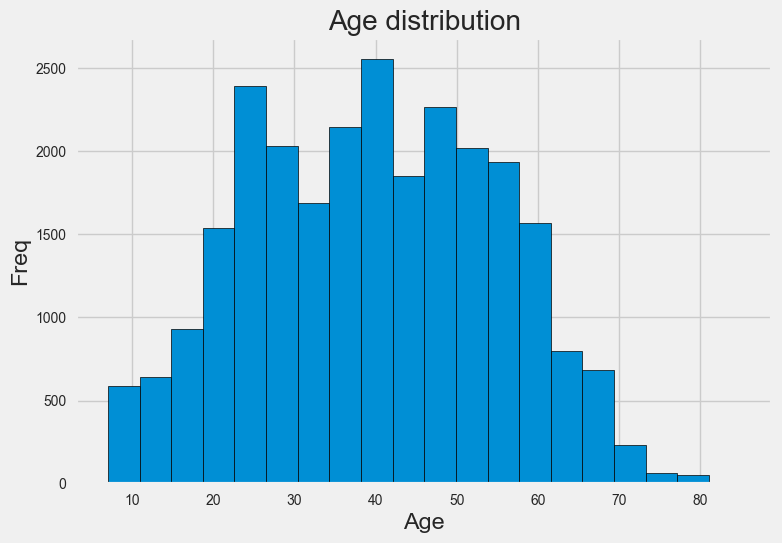

In [38]:
bins = 20
plt.hist(df['Age'], bins=bins,edgecolor='black')

plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Freq')

#plt.tight_layout()

satisfaction by gender


Text(0, 0.5, 'Freq')

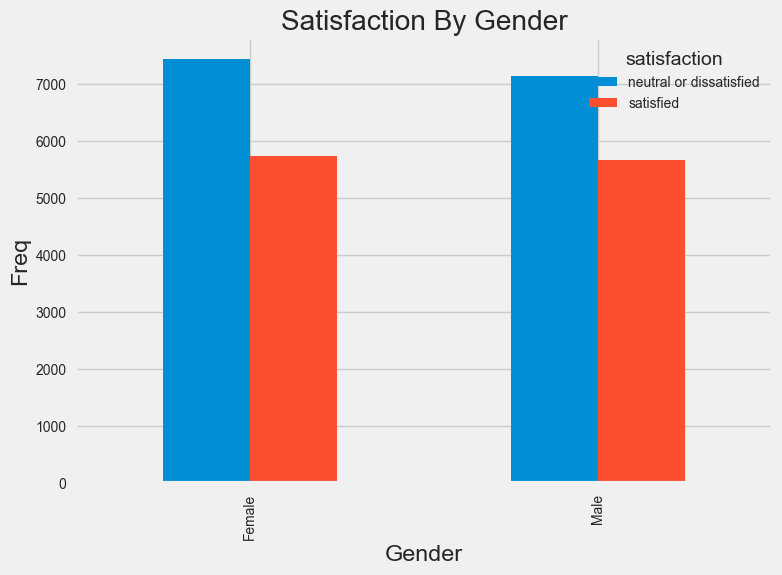

In [39]:
gender_sat = (
    df.groupby("Gender")["satisfaction"]
      .value_counts()
      .unstack()
)

gender_sat.plot(kind='bar')
plt.title('Satisfaction By Gender')
plt.ylabel('Freq')

Travel Class

Text(0, 0.5, 'Freq')

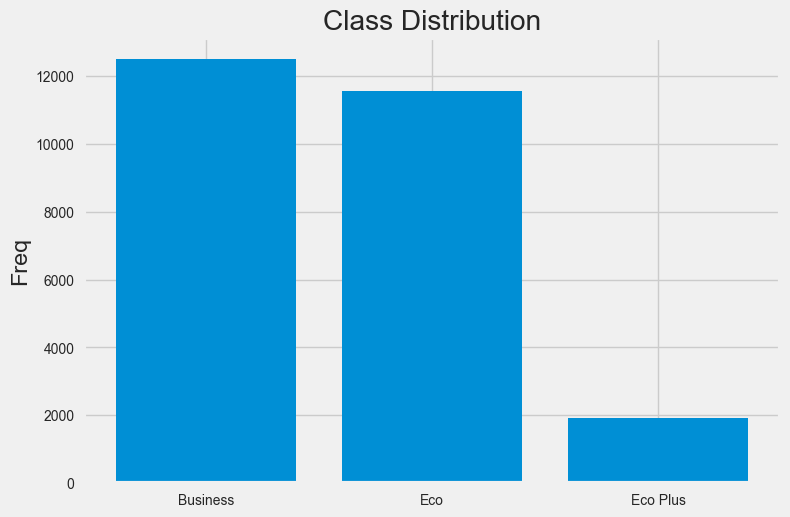

In [40]:
class_counts = df["Class"].value_counts()

plt.bar(class_counts.index, class_counts.values)
plt.title('Class Distribution')
plt.ylabel('Freq')

Satisfaction By Class

Text(0, 0.5, 'Freq')

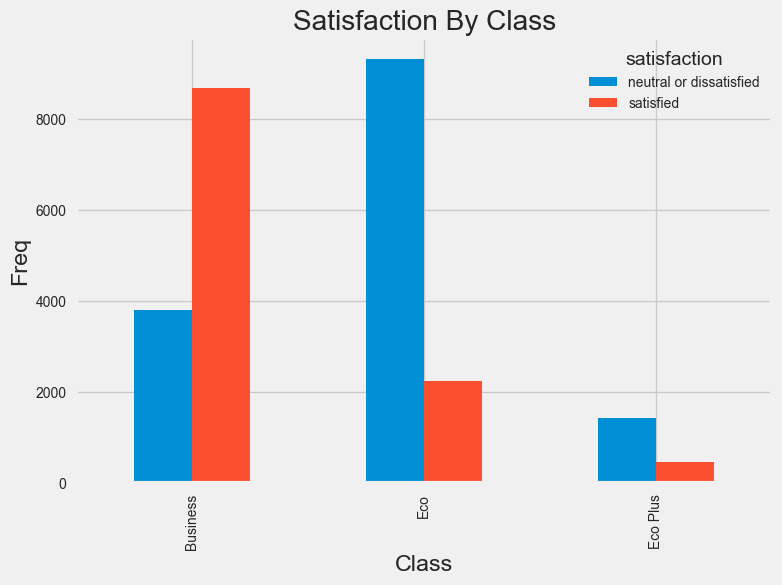

In [42]:
class_sat = (
    df.groupby('Class')['satisfaction']
      .value_counts()
      .unstack()
)

class_sat.plot(kind='bar')
plt.title('Satisfaction By Class')
plt.ylabel('Freq')

Satisfaction by flight distance

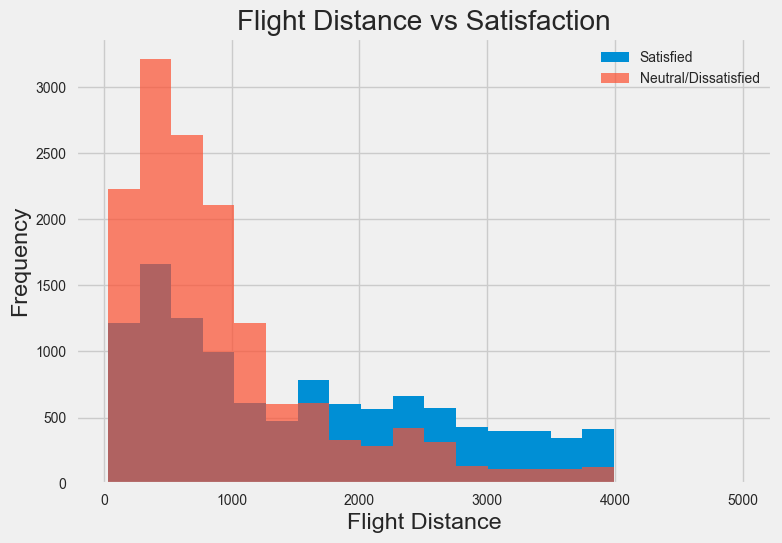

In [52]:
satisfied = df[df['satisfaction'] == 'satisfied']['Flight Distance']
unsatisfied = df[df["satisfaction"] == "neutral or dissatisfied"]["Flight Distance"]

plt.hist(satisfied, bins=20, alpha=1, label="Satisfied")
plt.hist(unsatisfied, bins=20, alpha=0.7, label="Neutral/Dissatisfied")
plt.title('Flight Distance vs Satisfaction')
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.legend()

Delay Vs Satisfaction

Text(0, 0.5, 'Average Delay')

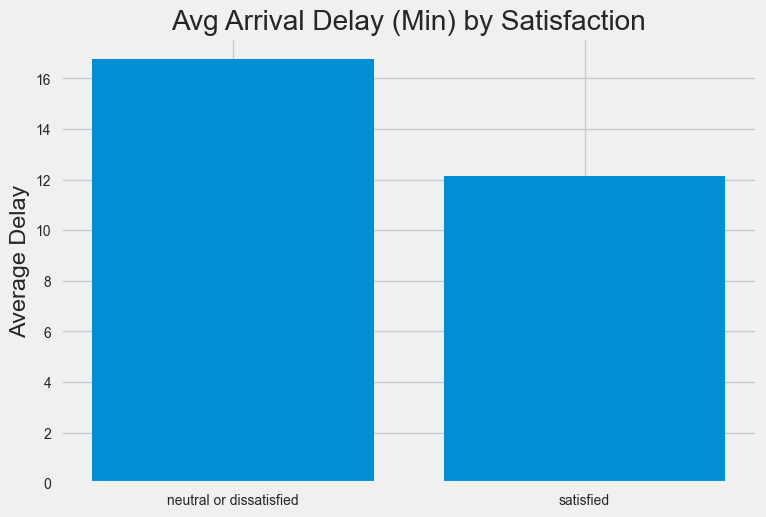

In [54]:
delay_avg = df.groupby('satisfaction')['Arrival Delay in Minutes'].mean()

plt.bar(delay_avg.index, delay_avg.values)
plt.title('Avg Arrival Delay (Min) by Satisfaction')
plt.ylabel('Average Delay')

Services Rating

Text(0.5, 0, 'Average Rating')

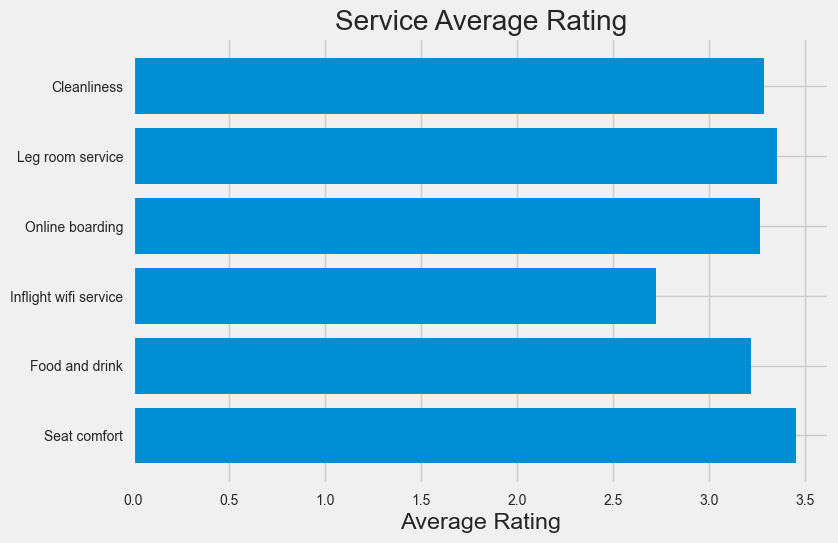

In [60]:
services = [
    "Seat comfort", "Food and drink", "Inflight wifi service",
    "Online boarding", "Leg room service", "Cleanliness"
]

Service_Avg = df[services].mean()
plt.barh(Service_Avg.index,Service_Avg.values)
plt.title('Service Average Rating')
plt.xlabel('Average Rating')

Service and Satisfaction

Text(0, 0.5, 'Average Rating')

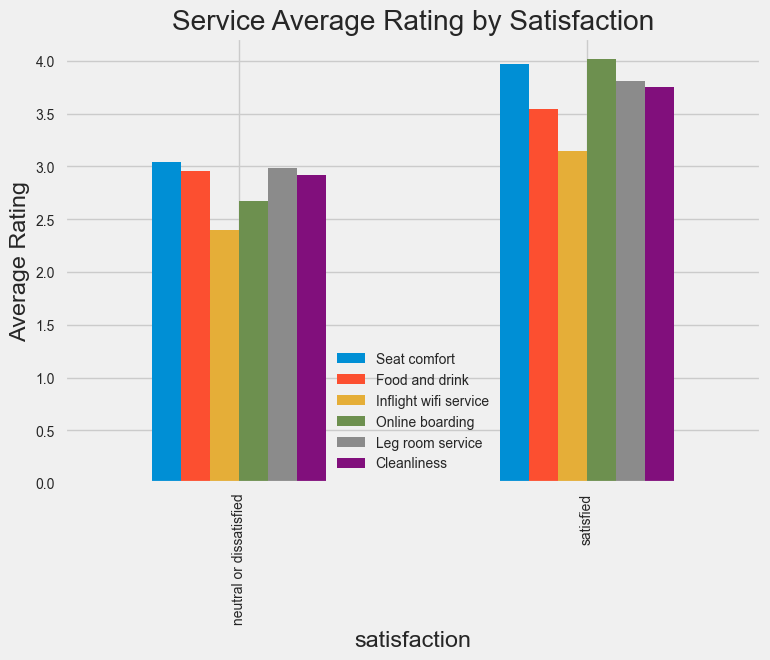

In [62]:
service_by_sat = df.groupby('satisfaction')[services].mean()

service_by_sat.plot(kind='bar')
plt.title('Service Average Rating by Satisfaction')
plt.ylabel('Average Rating')

Seat and class

Text(0, 0.5, 'Average Rating')

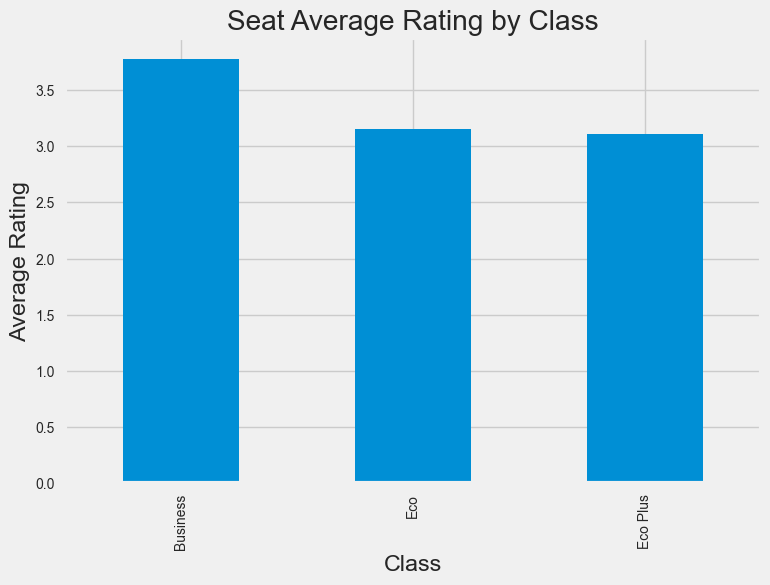

In [65]:
seat_by_class = df.groupby('Class')['Seat comfort'].mean()

seat_by_class.plot(kind='bar')
plt.title('Seat Average Rating by Class')
plt.ylabel('Average Seat Rating')